In [1]:
# In cell 1

import nltk
from nltk.corpus import treebank
import numpy as np
import re
from collections import Counter
# Removed unused imports: statistics, matplotlib.pyplot

# Download and load corpus
nltk.download('treebank', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# --- Data Cleaning Function ---
# Regex to identify trace tokens and empty categories in Treebank
TRACE_TOKEN_PATTERN = re.compile(r'^\*.*\*$|^\*$|^\*-?\d+$|^0$')
def is_valid_token(word, pos_tag=None):
    """Checks if a token is valid (not a trace or -NONE- tag)."""
    if pos_tag == '-NONE-':
        return False
    if TRACE_TOKEN_PATTERN.match(word):
        return False
    return True

# --- Load and Clean Sentences ---
original_tagged_sentences = treebank.tagged_sents()
cleaned_tagged_sentences = []
for sentence in original_tagged_sentences:
    # Filter out invalid tokens from each sentence
    cleaned_tokens = [(word, pos) for word, pos in sentence if is_valid_token(word, pos)]

    if cleaned_tokens:
        cleaned_tagged_sentences.append(cleaned_tokens)

# Check if any sentences remain after cleaning
if not cleaned_tagged_sentences:
    raise ValueError("No valid sentences found after cleaning. Check the cleaning logic and corpus.")

# --- Prepare Data for Modeling ---
# We keep the variable name 'filtered_...' for consistency with subsequent cells
filtered_tagged_sentences = cleaned_tagged_sentences

# Create list of sentence strings (plain text) for BERT input
filtered_sentences_text = [" ".join([word for word, pos in sentence]) for sentence in filtered_tagged_sentences]

# --- Create Target Variable (Verb Presence) ---
# Define the set of Penn Treebank tags considered as verbs
VERB_TAGS = {'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ'}
y = []
for sentence in filtered_tagged_sentences:
    # Check if any token in the sentence has a verb tag
    has_verb = any(pos in VERB_TAGS for word, pos in sentence)
    y.append(1 if has_verb else 0) # 1 if verb present, 0 otherwise
y = np.array(y) 

# --- Gather Basic Statistics on the Final Dataset ---
final_total_sentences = len(filtered_tagged_sentences)
final_all_tokens = [word for sentence in filtered_tagged_sentences for word, pos in sentence]
final_total_tokens = len(final_all_tokens)
final_unique_tokens = set(final_all_tokens)
final_total_unique_tokens = len(final_unique_tokens)

# Verb presence statistics using the target variable 'y'
verb_counts = Counter(y)
sentences_with_verbs = verb_counts.get(1, 0) 
sentences_without_verbs = verb_counts.get(0, 0)

# --- Print Statistics ---
print(f"Original tagged sentences from Treebank: {len(original_tagged_sentences)}")
print(f"Sentences after cleaning (used for analysis): {final_total_sentences}")
print("\n--- Statistics for Final Dataset ---")
if final_total_sentences > 0:
    print(f"Sentences containing at least one verb: {sentences_with_verbs} ({sentences_with_verbs/final_total_sentences:.2%})")
    print(f"Sentences containing no verbs: {sentences_without_verbs} ({sentences_without_verbs/final_total_sentences:.2%})")
else:
    print("Sentences containing at least one verb: 0 (0.00%)")
    print("Sentences containing no verbs: 0 (0.00%)")
print(f"Total number of tokens (words): {final_total_tokens}")
print(f"Total number of unique tokens (vocabulary size): {final_total_unique_tokens}")

# Verify shapes for downstream tasks
print(f"\nShape of text sentences list: ({len(filtered_sentences_text)},)")
print(f"Shape of target variable 'y': {y.shape}")

Original tagged sentences from Treebank: 3914
Sentences after cleaning (used for analysis): 3914

--- Statistics for Final Dataset ---
Sentences containing at least one verb: 3808 (97.29%)
Sentences containing no verbs: 106 (2.71%)
Total number of tokens (words): 94084
Total number of unique tokens (vocabulary size): 11968

Shape of text sentences list: (3914,)
Shape of target variable 'y': (3914,)


In [2]:
print(filtered_tagged_sentences[0])

[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ'), (',', ','), ('will', 'MD'), ('join', 'VB'), ('the', 'DT'), ('board', 'NN'), ('as', 'IN'), ('a', 'DT'), ('nonexecutive', 'JJ'), ('director', 'NN'), ('Nov.', 'NNP'), ('29', 'CD'), ('.', '.')]


In [3]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embeddings_no_padding(texts):
    embeddings = []
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    model.eval()
    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, padding=False, truncation=True, return_tensors='pt').to(device)
            outputs = model(**inputs)
            emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(emb[0])
    return np.array(embeddings)


print("Generating BERT embeddings for filtered_sentences_text")
# Use the text sentences derived from the filtered tagged sentences
X_sentence_features = get_bert_embeddings_no_padding(filtered_sentences_text)
print(f"Sentence BERT embeddings shape: {X_sentence_features.shape}")
print(f"Target variable 'y' (verb presence) shape: {y.shape}")


Generating BERT embeddings for filtered_sentences_text
Sentence BERT embeddings shape: (3914, 768)
Target variable 'y' (verb presence) shape: (3914,)


In [4]:
# In cell 4

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.ensemble import BalancedRandomForestClassifier
import numpy as np

# Target y (verb presence) is already defined in the first cell

# Split data into train and test sets
# Ensure stratification if class imbalance is significant
X_train, X_test, y_train, y_test = train_test_split(
    X_sentence_features, y, test_size=0.2, random_state=42, stratify=y
)

# --- Logistic Regression (with class weighting) ---
print("--- Logistic Regression Evaluation (class_weight='balanced') ---")
log_reg = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test) 
# Evaluate Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"\nTest Accuracy: {accuracy_lr:.3f}")
print(f"Test Precision (Verb Present): {precision_lr:.3f}")
print(f"Test Recall (Verb Present): {recall_lr:.3f}")
print(f"Test F1-Score (Verb Present): {f1_lr:.3f}")
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr, target_names=['No Verb', 'Verb Present']))


conf_matrix_lr = confusion_matrix(y_test, y_pred_lr) 


# --- Balanced Random Forest ---
print("\n\n--- Balanced Random Forest Evaluation ---")
brf = BalancedRandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) 
brf.fit(X_train, y_train)
y_pred_brf = brf.predict(X_test) 

# Evaluate Balanced Random Forest
accuracy_brf = accuracy_score(y_test, y_pred_brf)
precision_brf = precision_score(y_test, y_pred_brf)
recall_brf = recall_score(y_test, y_pred_brf)
f1_brf = f1_score(y_test, y_pred_brf)

print(f"\nTest Accuracy: {accuracy_brf:.3f}")
print(f"Test Precision (Verb Present): {precision_brf:.3f}")
print(f"Test Recall (Verb Present): {recall_brf:.3f}")
print(f"Test F1-Score (Verb Present): {f1_brf:.3f}")
print("\nClassification Report (Balanced Random Forest):")
print(classification_report(y_test, y_pred_brf, target_names=['No Verb', 'Verb Present']))

# Calculate confusion matrix for Balanced Random Forest
conf_matrix_brf = confusion_matrix(y_test, y_pred_brf) 

--- Logistic Regression Evaluation (class_weight='balanced') ---

Test Accuracy: 0.987
Test Precision (Verb Present): 0.995
Test Recall (Verb Present): 0.992
Test F1-Score (Verb Present): 0.993

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

     No Verb       0.74      0.81      0.77        21
Verb Present       0.99      0.99      0.99       762

    accuracy                           0.99       783
   macro avg       0.87      0.90      0.88       783
weighted avg       0.99      0.99      0.99       783



--- Balanced Random Forest Evaluation ---

Test Accuracy: 0.974
Test Precision (Verb Present): 0.997
Test Recall (Verb Present): 0.976
Test F1-Score (Verb Present): 0.987

Classification Report (Balanced Random Forest):
              precision    recall  f1-score   support

     No Verb       0.51      0.90      0.66        21
Verb Present       1.00      0.98      0.99       762

    accuracy                           0.97    

In [5]:
# In cell 5

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from imblearn.ensemble import BalancedRandomForestClassifier

# --- Logistic Regression Cross-Validation ---
print("--- Logistic Regression Cross-Validation Results (5-fold) ---")
log_reg_cv = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores_lr = cross_val_score(log_reg_cv, X_sentence_features, y, cv=skf, scoring='accuracy')
precision_scores_lr = cross_val_score(log_reg_cv, X_sentence_features, y, cv=skf, scoring='precision')
recall_scores_lr = cross_val_score(log_reg_cv, X_sentence_features, y, cv=skf, scoring='recall')
f1_scores_lr = cross_val_score(log_reg_cv, X_sentence_features, y, cv=skf, scoring='f1')

print(f"Cross-validated Accuracy: {accuracy_scores_lr.mean():.3f} (+/- {accuracy_scores_lr.std() * 2:.3f})")
print(f"Cross-validated Precision: {precision_scores_lr.mean():.3f} (+/- {precision_scores_lr.std() * 2:.3f})")
print(f"Cross-validated Recall: {recall_scores_lr.mean():.3f} (+/- {recall_scores_lr.std() * 2:.3f})")
print(f"Cross-validated F1-Score: {f1_scores_lr.mean():.3f} (+/- {f1_scores_lr.std() * 2:.3f})")


# --- Balanced Random Forest Cross-Validation ---
print("\n\n--- Balanced Random Forest Cross-Validation Results (5-fold) ---")
brf_cv = BalancedRandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # Use same params as in Cell 4


accuracy_scores_brf = cross_val_score(brf_cv, X_sentence_features, y, cv=skf, scoring='accuracy', n_jobs=-1) # Parallelize CV if possible
precision_scores_brf = cross_val_score(brf_cv, X_sentence_features, y, cv=skf, scoring='precision', n_jobs=-1)
recall_scores_brf = cross_val_score(brf_cv, X_sentence_features, y, cv=skf, scoring='recall', n_jobs=-1)
f1_scores_brf = cross_val_score(brf_cv, X_sentence_features, y, cv=skf, scoring='f1', n_jobs=-1)

print(f"Cross-validated Accuracy: {accuracy_scores_brf.mean():.3f} (+/- {accuracy_scores_brf.std() * 2:.3f})")
print(f"Cross-validated Precision: {precision_scores_brf.mean():.3f} (+/- {precision_scores_brf.std() * 2:.3f})")
print(f"Cross-validated Recall: {recall_scores_brf.mean():.3f} (+/- {recall_scores_brf.std() * 2:.3f})")
print(f"Cross-validated F1-Score: {f1_scores_brf.mean():.3f} (+/- {f1_scores_brf.std() * 2:.3f})")

--- Logistic Regression Cross-Validation Results (5-fold) ---
Cross-validated Accuracy: 0.990 (+/- 0.010)
Cross-validated Precision: 0.997 (+/- 0.004)
Cross-validated Recall: 0.992 (+/- 0.008)
Cross-validated F1-Score: 0.995 (+/- 0.005)


--- Balanced Random Forest Cross-Validation Results (5-fold) ---
Cross-validated Accuracy: 0.974 (+/- 0.012)
Cross-validated Precision: 0.998 (+/- 0.005)
Cross-validated Recall: 0.976 (+/- 0.008)
Cross-validated F1-Score: 0.987 (+/- 0.006)


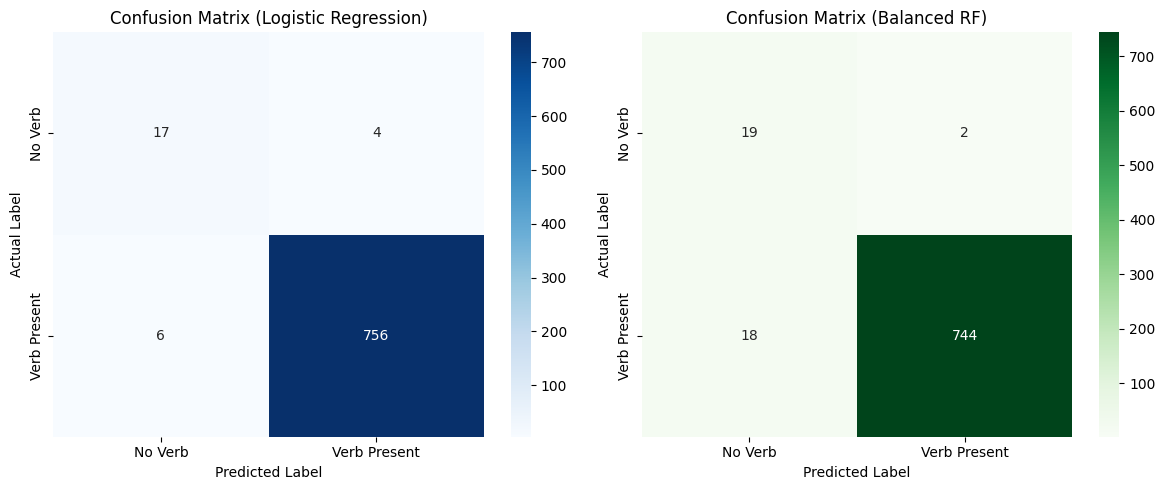

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


# Plot Confusion Matrix for Logistic Regression
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, plot 1
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Verb', 'Verb Present'],
            yticklabels=['No Verb', 'Verb Present'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Logistic Regression)")

# Plot Confusion Matrix for Balanced Random Forest
plt.subplot(1, 2, 2) 
sns.heatmap(conf_matrix_brf, annot=True, fmt='d', cmap='Greens', # different color map
            xticklabels=['No Verb', 'Verb Present'],
            yticklabels=['No Verb', 'Verb Present'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Balanced RF)")

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()